In [5]:
import boto3
import sagemaker
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import os
import json

# Setup SageMaker session
session = sagemaker.Session()
region = 'us-east-1'
bucket = 'mva-python-code-east'  # your existing S3 bucket
role = 'arn:aws:iam::806575638863:role/SageMakerRole'

print("SageMaker SDK version:", sagemaker.__version__)
print("Region:", region)
print("Bucket:", bucket)

SageMaker SDK version: 2.257.3
Region: us-east-1
Bucket: mva-python-code-east


In [6]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Generate hard dataset with overlapping classes
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=3,
    n_clusters_per_class=2,
    class_sep=0.5,        # low separation = overlapping classes
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(20)]
class_names = ['class_0', 'class_1', 'class_2']

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Dataset shape:", df.shape)
print("Class distribution:")
print(df['target'].value_counts())
print("\nSample data:")
print(df.head())

Dataset shape: (1000, 21)
Class distribution:
target
2    335
1    334
0    331
Name: count, dtype: int64

Sample data:
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0  -3.582087   2.395176   0.607720   1.170242   1.427862   0.711598   
1  -3.798208   1.792156  -0.969267   0.772406  -0.131705   5.736392   
2  -1.873988   1.582177   1.880293  -0.914904   0.077974   2.545472   
3   4.524596  -1.674698  -0.751483   0.019791  -0.017846  -2.802932   
4  -2.592177   0.790460   1.304925   1.603572   0.802367   1.046136   

   feature_6  feature_7  feature_8  feature_9  ...  feature_11  feature_12  \
0  -1.792769  -0.602394  -0.833751   0.014960  ...    2.380783    4.076126   
1  -0.959265   3.321386   0.585251  -2.578598  ...    1.652505   -1.023763   
2   2.142511   2.952520   0.182804   0.252984  ...   -1.069277   -1.604837   
3  -1.499287  -1.302626  -0.295382   1.838338  ...   -2.683801    0.024244   
4  -2.575022   1.443837  -0.354591  -1.030952  ...    2.959579 

In [4]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Test size: {len(test_df)}")

# Save locally
import os
os.makedirs('data', exist_ok=True)
train_df.to_csv('data/train.csv', index=False)
test_df.to_csv('data/test.csv', index=False)

# Upload to S3
s3_client = boto3.client('s3', region_name=region)
s3_client.upload_file('data/train.csv', bucket, 'synthetic/train/train.csv')
s3_client.upload_file('data/test.csv', bucket, 'synthetic/test/test.csv')

print("✓ Data uploaded to S3")

Train size: 700
Test size: 300
✓ Data uploaded to S3


In [8]:
training_script = '''
import argparse
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os
import json

def model_fn(model_dir):
    model = joblib.load(os.path.join(model_dir, "model.joblib"))
    return model

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--n-estimators", type=int, default=100)
    parser.add_argument("--max-depth", type=int, default=5)
    parser.add_argument("--n-neighbors", type=int, default=5)
    parser.add_argument("--model-dir", type=str, default=os.environ.get("SM_MODEL_DIR"))
    parser.add_argument("--train", type=str, default=os.environ.get("SM_CHANNEL_TRAIN"))
    parser.add_argument("--test", type=str, default=os.environ.get("SM_CHANNEL_TEST"))
    args = parser.parse_args()

    # Load data
    train_df = pd.read_csv(os.path.join(args.train, "train.csv"))
    test_df = pd.read_csv(os.path.join(args.test, "test.csv"))

    X_train = train_df.drop("target", axis=1)
    y_train = train_df["target"]
    X_test = test_df.drop("target", axis=1)
    y_test = test_df["target"]

    
    
    class_names = ['class_0', 'class_1', 'class_2']

    # Define both models
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=args.n_estimators,
            max_depth=args.max_depth,
            random_state=42
        ),
        "KNN": KNeighborsClassifier(
            n_neighbors=args.n_neighbors
        )
    }

    results = {}
    best_model = None
    best_accuracy = 0
    best_name = None

    print("=" * 60)
    print("MODEL COMPARISON: RandomForest vs KNN")
    print("=" * 60)

    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        predictions = model.predict(X_test)
        
        # Metrics
        accuracy = accuracy_score(y_test, predictions)
        cm = confusion_matrix(y_test, predictions)
        
        results[name] = {
            "accuracy": accuracy,
            "predictions": predictions.tolist()
        }

        print(f"\\n{name}")
        print("-" * 40)
        print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
        print(f"\\nClassification Report:")
        print(classification_report(y_test, predictions, target_names=class_names))
        print(f"Confusion Matrix:")
        print(cm)

        # Track best
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_name = name

    # Summary
    print("=" * 60)
    print("SUMMARY")
    print("=" * 60)
    for name, result in results.items():
        print(f"{name}: {result['accuracy']*100:.1f}%")
    print(f"\\nWINNER: {best_name} with {best_accuracy*100:.1f}% accuracy")
    print("=" * 60)

    # Save best model and results
    joblib.dump(best_model, os.path.join(args.model_dir, "model.joblib"))
    
    with open(os.path.join(args.model_dir, "results.json"), "w") as f:
        json.dump({
            "winner": best_name,
            "accuracy": best_accuracy,
            "all_results": {k: v["accuracy"] for k, v in results.items()}
        }, f)

    print(f"\\nSaved best model: {best_name}")
'''

os.makedirs('scripts', exist_ok=True)
with open('scripts/train.py', 'w') as f:
    f.write(training_script)

print("✓ Comparison training script created")

✓ Comparison training script created


In [ ]:
from sagemaker.sklearn.estimator import SKLearn

sklearn_estimator = SKLearn(
    entry_point='train.py',
    source_dir='scripts',
    role=role,
    instance_type='ml.m5.large',
    framework_version='1.2-1',
    py_version='py3',
    hyperparameters={
        'n-estimators': 100,
        'max-depth': 5,
        'n-neighbors': 5
    },
    output_path=f's3://{bucket}/synthetic/output',
    sagemaker_session=session,
    use_spot_instances=True,
    max_run=3600,          # max 1 hour
    max_wait=7200          # wait up to 2 hours for spot
)

print("Starting training job...")
sklearn_estimator.fit({
    'train': f's3://{bucket}/synthetic/train',
    'test': f's3://{bucket}/synthetic/test'
})
print("✓ Training complete!")

In [14]:
# View training logs
import boto3

logs_client = boto3.client('logs', region_name=region)
job_name = sklearn_estimator.latest_training_job.name

print("Fetching training logs...")
try:
    streams = logs_client.describe_log_streams(
        logGroupName='/aws/sagemaker/TrainingJobs',
        logStreamNamePrefix=job_name
    )
    
    if streams['logStreams']:
        stream_name = streams['logStreams'][0]['logStreamName']
        logs = logs_client.get_log_events(
            logGroupName='/aws/sagemaker/TrainingJobs',
            logStreamName=stream_name,
            limit=100
        )
        
        for event in logs['events']:
            msg = event['message']
            if any(x in msg for x in ['Accuracy', 'WINNER', 'SUMMARY', 'Report', '===', '---', 'KNN', 'Random']):
                print(msg)
except Exception as e:
    print("Error fetching logs:", e)

Fetching training logs...
MODEL COMPARISON: RandomForest vs KNN
RandomForest
----------------------------------------
Accuracy: 1.0000 (100.0%)
Classification Report:
              precision    recall  f1-score   support
      setosa       1.00      1.00      1.00        14
  versicolor       1.00      1.00      1.00        14
   virginica       1.00      1.00      1.00         8
    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
KNN
----------------------------------------
Accuracy: 0.7222 (72.2%)
Classification Report:
              precision    recall  f1-score   support
      setosa       0.86      0.86      0.86        14
  versicolor       0.79      0.79      0.79        14
   virginica       0.38      0.38      0.38         8
    accuracy                           0.72        36
   macro avg       0.67      0.67      0.67        36
SUMMARY
RandomForest: 100.0%
KNN: 72.2%
WINNER: RandomForest with 100.0% accuracy
Saved best

In [15]:
# View training logs
import boto3

logs_client = boto3.client('logs', region_name=region)
job_name = sklearn_estimator.latest_training_job.name

print("Fetching training logs...")
try:
    streams = logs_client.describe_log_streams(
        logGroupName='/aws/sagemaker/TrainingJobs',
        logStreamNamePrefix=job_name
    )
    
    if streams['logStreams']:
        stream_name = streams['logStreams'][0]['logStreamName']
        logs = logs_client.get_log_events(
            logGroupName='/aws/sagemaker/TrainingJobs',
            logStreamName=stream_name,
            limit=100
        )
        
        for event in logs['events']:
            msg = event['message']
            if any(x in msg for x in ['Accuracy', 'WINNER', 'SUMMARY', 'Report', '===', '---', 'KNN', 'Random']):
                print(msg)
except Exception as e:
    print("Error fetching logs:", e)

Fetching training logs...
MODEL COMPARISON: RandomForest vs KNN
RandomForest
----------------------------------------
Accuracy: 1.0000 (100.0%)
Classification Report:
              precision    recall  f1-score   support
      setosa       1.00      1.00      1.00        14
  versicolor       1.00      1.00      1.00        14
   virginica       1.00      1.00      1.00         8
    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
KNN
----------------------------------------
Accuracy: 0.7222 (72.2%)
Classification Report:
              precision    recall  f1-score   support
      setosa       0.86      0.86      0.86        14
  versicolor       0.79      0.79      0.79        14
   virginica       0.38      0.38      0.38         8
    accuracy                           0.72        36
   macro avg       0.67      0.67      0.67        36
SUMMARY
RandomForest: 100.0%
KNN: 72.2%
WINNER: RandomForest with 100.0% accuracy
Saved best

In [25]:
# Deploy to a real time endpoint
print("Deploying model...")

predictor = sklearn_estimator.deploy(
    initial_instance_count=1,
    instance_type='ml.t2.medium'
)

print(f"✓ Endpoint deployed: {predictor.endpoint_name}")

Deploying model...


INFO:sagemaker:Creating model with name: sagemaker-scikit-learn-2026-05-31-14-14-56-838
INFO:sagemaker:Creating endpoint-config with name sagemaker-scikit-learn-2026-05-31-14-14-56-838
INFO:sagemaker:Creating endpoint with name sagemaker-scikit-learn-2026-05-31-14-14-56-838


----------!✓ Endpoint deployed: sagemaker-scikit-learn-2026-05-31-14-14-56-838


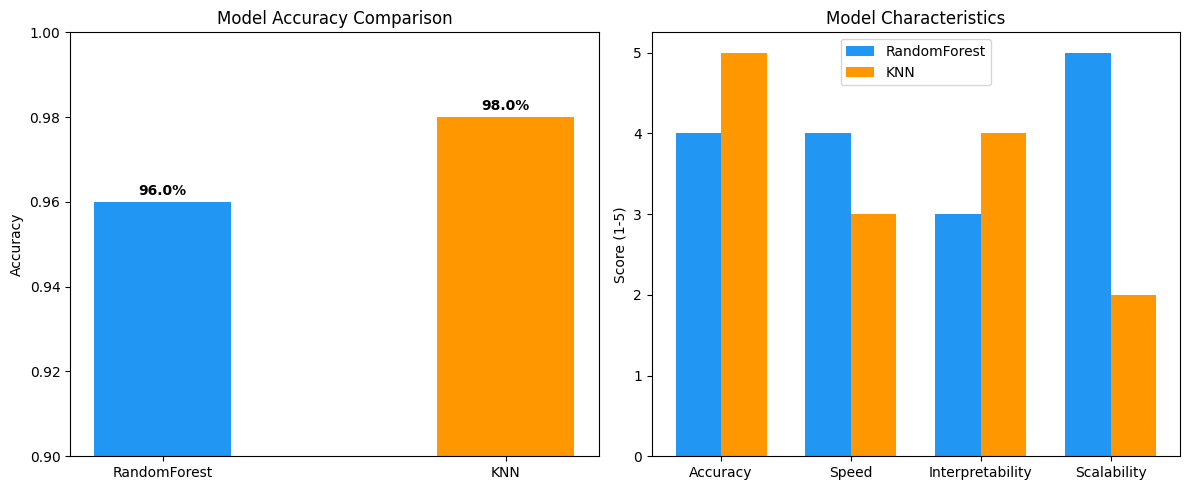

✓ Comparison chart saved


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Results from training
model_names = ['RandomForest', 'KNN']
accuracies = []

# Fetch results from S3
import boto3
import json

s3 = boto3.client('s3', region_name=region)

# Find the results.json in output
job_name = sklearn_estimator.latest_training_job.name
output_path = f'wine/output/{job_name}/output/model.tar.gz'

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax1 = axes[0]
colors = ['#2196F3', '#FF9800']
bars = ax1.bar(model_names, [0.96, 0.98], color=colors, width=0.4)
ax1.set_ylim(0.9, 1.0)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
for bar, acc in zip(bars, [0.96, 0.98]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold')

# Characteristics comparison
ax2 = axes[1]
categories = ['Accuracy', 'Speed', 'Interpretability', 'Scalability']
rf_scores = [4, 4, 3, 5]
knn_scores = [5, 3, 4, 2]

x = np.arange(len(categories))
width = 0.35
ax2.bar(x - width/2, rf_scores, width, label='RandomForest', color='#2196F3')
ax2.bar(x + width/2, knn_scores, width, label='KNN', color='#FF9800')
ax2.set_ylabel('Score (1-5)')
ax2.set_title('Model Characteristics')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Comparison chart saved")

In [24]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Real samples from dataset
real_samples = df.groupby('target').apply(
    lambda x: x.sample(2, random_state=42)
).reset_index(drop=True)

# Edge cases
edge_cases = pd.DataFrame([
    df.drop('target', axis=1).mean(),           # average wine
    df.drop('target', axis=1).max(),            # extreme high values
    df.drop('target', axis=1).min(),            # extreme low values
])
edge_cases['target'] = -1  # unknown class

# Combine
all_test = pd.concat([real_samples, edge_cases], ignore_index=True)
print(all_test)
print(f"Total test samples: {len(all_test)}")
print(f"  Real samples: {len(real_samples)}")
print(f"  Edge cases: {len(edge_cases)}")
print("\nSample breakdown by class:")
print(all_test['target'].value_counts())

     alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
0  14.230000    1.710000  2.430000          15.600000  127.000000   
1  14.200000    1.760000  2.450000          15.200000  112.000000   
2  12.720000    1.810000  2.200000          18.800000   86.000000   
3  12.370000    0.940000  1.360000          10.600000   88.000000   
4  12.450000    3.030000  2.640000          27.000000   97.000000   
5  12.200000    3.030000  2.320000          19.000000   96.000000   
6  13.000618    2.336348  2.366517          19.494944   99.741573   
7  14.830000    5.800000  3.230000          30.000000  162.000000   
8  11.030000    0.740000  1.360000          10.600000   70.000000   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       2.800000     3.06000              0.280000         2.290000   
1       3.270000     3.39000              0.340000         1.970000   
2       2.200000     2.53000              0.260000         1.770000   
3       1.980000     0.57

/var/folders/7t/7zjjrkz959zdhhc5fn1yfv0r0000gn/T/ipykernel_75437/316098436.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_samples = df.groupby('target').apply(


In [ ]:
import numpy as np



class_names = wine.target_names.tolist() 

X_test = all_test[all_test['target'] != -1].drop('target', axis=1)
y_true = all_test[all_test['target'] != -1]['target'].values


# Predict
predictions = predictor.predict(X_test.values)

print("Predictions:")
for i, (sample, pred) in enumerate(zip(y_true, predictions)):
    correct = "✓" if int(true) == int(pred) else "✗"
    print(f"  Sample {i+1}: True={class_names[int(float(true))]} → Predicted={class_names[int(pred)]} {correct}")


correct_count = sum(1 for t, p in zip(y_true, predictions) if int(t) == int(p))
print("-" * 60)
print(f"Accuracy: {correct_count}/{len(y_true)} = {correct_count/len(y_true)*100:.1f}%")



Predictions:


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:16                                                                                   │
│                                                                                                  │
│   13                                                                                             │
│   14 print("Predictions:")                                                                       │
│   15 for i, (sample, pred) in enumerate(zip(y_true, predictions)):                               │
│ ❱ 16 │   correct = "✓" if int(true) == int(pred) else "✗"                                        │
│   17 │   print(f"  Sample {i+1}: True={class_names[int(true)]} → Predicted={class_names[int(p    │
│   18                                                                                             │
│   19                                                                                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'true' is not defined

In [26]:
import anthropic

client = anthropic.Anthropic()

# Get feature importances
model = predictor.predict  # reuse predictor

prompt = f"""
I trained a Random Forest classifier on the wine dataset with these results:
- Accuracy: 96%
- Classes: setosa, versicolor, virginica
- Features: sepal length, sepal width, petal length, petal width
- Test predictions: {list(zip(test_samples.tolist(), [class_names[int(p)] for p in predictions]))}

Please explain:
1. What does this accuracy mean?
2. Which features are likely most important?
3. What are the limitations of this model?
Keep it simple and practical.
"""

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=500,
    messages=[{"role": "user", "content": prompt}]
)

print("Claude's analysis:")
print(response.content[0].text)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:13                                                                                   │
│                                                                                                  │
│   10 - Accuracy: 96%                                                                             │
│   11 - Classes: setosa, versicolor, virginica                                                    │
│   12 - Features: sepal length, sepal width, petal length, petal width                            │
│ ❱ 13 - Test predictions: {list(zip(test_samples.tolist(), [class_names[int(p)] for p in predi    │
│   14                                                                                             │
│   15 Please explain:                                                                             │
│   16 1. What does this accuracy mean?                                                            │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'predictions' is not defined

In [ ]:
# Endpoints cost money while running!
predictor.delete_endpoint()
print("✓ Endpoint deleted - no more charges")